# Coffee Shop Sales Analysis
## Exploring Revenue Drivers and Customer Behavior in Coffee Retail
### Author: Brenna Coe | July 2026
### Tools: Python, SQL, Tableau
---

## The Question
What factors drive revenue performance across dayparts, products, 
and store locations in an urban coffee shop chain?

## The Data
- 149,116 transactions across 3 NYC store locations
- Date range: June 2023 — present
- Source: Coffee Shop Sales dataset (Kaggle)
- 18 variables including transaction time, product category, 
  store location, and total bill

In [100]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/divu2001/coffee-shop-sales-analysis/Project.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Shape: (149116, 18)

Columns: ['transaction_id', 'transaction_date', 'transaction_time', 'store_id', 'store_location', 'product_id', 'transaction_qty', 'unit_price', 'Total_Bill', 'product_category', 'product_type', 'product_detail', 'Size', 'Month Name', 'Day Name', 'Hour', 'Month', 'Day of Week']

First 5 rows:


,transaction_id,transaction_date,transaction_time,store_id,store_location,product_id,transaction_qty,unit_price,Total_Bill,product_category,product_type,product_detail,Size,Month Name,Day Name,Hour,Month,Day of Week
0,114301,01-06-2023,11:33:29,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Thursday,11,6,3
1,115405,02-06-2023,11:18:24,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,11,6,4
2,115478,02-06-2023,12:02:45,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,12,6,4
3,116288,02-06-2023,19:39:47,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,19,6,4
4,116714,03-06-2023,12:24:57,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Saturday,12,6,5


## Section 2 — Data Cleaning and Feature Engineering

In [101]:
# Fix data types
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True)
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')

# Confirm it worked
print(df[['transaction_date', 'transaction_time']].dtypes)

transaction_date    datetime64[ns]
transaction_time    datetime64[ns]
dtype: object


In [102]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
transaction_id      0
transaction_date    0
transaction_time    0
store_id            0
store_location      0
product_id          0
transaction_qty     0
unit_price          0
Total_Bill          0
product_category    0
product_type        0
product_detail      0
Size                0
Month Name          0
Day Name            0
Hour                0
Month               0
Day of Week         0
dtype: int64

Duplicate rows: 0


In [103]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

print("New column names:")
print(df.columns.tolist())

New column names:
['transaction_id', 'transaction_date', 'transaction_time', 'store_id', 'store_location', 'product_id', 'transaction_qty', 'unit_price', 'total_bill', 'product_category', 'product_type', 'product_detail', 'size', 'month_name', 'day_name', 'hour', 'month', 'day_of_week']


In [104]:
# Build daypart feature
def assign_daypart(hour):
    if 5 <= hour < 11:
        return 'Morning Rush'
    elif 11 <= hour < 14:
        return 'Midday'
    elif 14 <= hour < 17:
        return 'Afternoon Lull'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Off Hours'

df['daypart'] = df['hour'].apply(assign_daypart)

print("Daypart column created successfully!")
print(df['daypart'].head(10))

Daypart column created successfully!
0            Midday
1            Midday
2            Midday
3           Evening
4            Midday
5            Midday
6            Midday
7           Evening
8    Afternoon Lull
9    Afternoon Lull
Name: daypart, dtype: object


In [105]:
# Sanity check
print("Daypart distribution:")
print(df['daypart'].value_counts())

print("\nStore locations:")
print(df['store_location'].unique())

print("\nProduct categories:")
print(df['product_category'].unique())

print("\nFull cleaned dataframe sample:")
df.head()

Daypart distribution:
daypart
Morning Rush      71985
Midday            27188
Afternoon Lull    27005
Evening           22938
Name: count, dtype: int64

Store locations:
['Astoria' 'Lower Manhattan' "Hell's Kitchen"]

Product categories:
['Tea' 'Coffee' 'Bakery' 'Drinking Chocolate' 'Flavours' 'Loose Tea'
 'Packaged Chocolate' 'Branded' 'Coffee beans']

Full cleaned dataframe sample:


,transaction_id,transaction_date,transaction_time,store_id,store_location,product_id,transaction_qty,unit_price,total_bill,product_category,product_type,product_detail,size,month_name,day_name,hour,month,day_of_week,daypart
0,114301,2023-06-01,1900-01-01 11:33:29,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Thursday,11,6,3,Midday
1,115405,2023-06-02,1900-01-01 11:18:24,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,11,6,4,Midday
2,115478,2023-06-02,1900-01-01 12:02:45,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,12,6,4,Midday
3,116288,2023-06-02,1900-01-01 19:39:47,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,19,6,4,Evening
4,116714,2023-06-03,1900-01-01 12:24:57,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Saturday,12,6,5,Midday


## Section 3 — SQL Analysis
Using SQLite to query the cleaned dataframe and answer core business questions

In [106]:
import sqlite3

# Create a database and load dataframe into it
conn = sqlite3.connect('starbucks_analysis.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

print("Database created successfully!")
print("Table 'sales' loaded with", len(df), "rows")

Database created successfully!
Table 'sales' loaded with 149116 rows


### Query 1 — Revenue by Daypart
Testing our core hypothesis: does Morning Rush dominate revenue?

In [107]:
q1 = pd.read_sql_query("""
    SELECT 
        daypart,
        COUNT(*) as transaction_count,
        ROUND(SUM(total_bill), 2) as total_revenue,
        ROUND(AVG(total_bill), 2) as avg_transaction_value
    FROM sales
    GROUP BY daypart
    ORDER BY total_revenue DESC
""", conn)

print(q1)

          daypart  transaction_count  total_revenue  avg_transaction_value
0    Morning Rush              71985      341969.53                   4.75
1          Midday              27188      126879.38                   4.67
2  Afternoon Lull              27005      124160.59                   4.60
3         Evening              22938      105802.83                   4.61


In [108]:
q2 = pd.read_sql_query("""
    SELECT 
        product_category,
        COUNT(*) as units_sold,
        ROUND(SUM(total_bill), 2) as total_revenue,
        ROUND(AVG(total_bill), 2) as avg_transaction_value
    FROM sales
    GROUP BY product_category
    ORDER BY total_revenue DESC
""", conn)

print(q2)

     product_category  units_sold  total_revenue  avg_transaction_value
0              Coffee       58416      269952.45                   4.62
1                 Tea       45449      196405.95                   4.32
2              Bakery       22796       82315.64                   3.61
3  Drinking Chocolate       11468       72416.00                   6.31
4        Coffee beans        1753       40085.25                  22.87
5             Branded         747       13607.00                  18.22
6           Loose Tea        1210       11213.60                   9.27
7            Flavours        6790        8408.80                   1.24
8  Packaged Chocolate         487        4407.64                   9.05


In [109]:
q3 = pd.read_sql_query("""
    SELECT 
        store_location,
        COUNT(*) as total_transactions,
        ROUND(SUM(total_bill), 2) as total_revenue,
        ROUND(AVG(total_bill), 2) as avg_transaction_value
    FROM sales
    GROUP BY store_location
    ORDER BY total_revenue DESC
""", conn)

print(q3)

    store_location  total_transactions  total_revenue  avg_transaction_value
0   Hell's Kitchen               50735      236511.17                   4.66
1          Astoria               50599      232243.91                   4.59
2  Lower Manhattan               47782      230057.25                   4.81


In [110]:
q4 = pd.read_sql_query("""
    SELECT 
        hour,
        COUNT(*) as transactions,
        ROUND(SUM(total_bill), 2) as total_revenue,
        ROUND(AVG(total_bill), 2) as avg_bill
    FROM sales
    GROUP BY hour
    ORDER BY total_revenue DESC
""", conn)

print(q4)

    hour  transactions  total_revenue  avg_bill
0     10         18545       88673.39      4.78
1      9         17764       85169.53      4.79
2      8         17654       82699.87      4.68
3      7         13428       63526.47      4.73
4     11          9766       46319.14      4.74
5     15          8979       41733.10      4.65
6     14          8933       41304.74      4.62
7     16          9093       41122.75      4.52
8     13          8714       40367.45      4.63
9     12          8708       40192.79      4.62
10    17          8745       40134.31      4.59
11    18          7498       34286.20      4.57
12    19          6092       28446.68      4.67
13     6          4594       21900.27      4.77
14    20           603        2935.64      4.87


In [111]:
q5 = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN day_name IN ('Saturday', 'Sunday') THEN 'Weekend'
            ELSE 'Weekday'
        END as day_type,
        COUNT(*) as transactions,
        ROUND(SUM(total_bill), 2) as total_revenue,
        ROUND(AVG(total_bill), 2) as avg_transaction_value
    FROM sales
    GROUP BY day_type
    ORDER BY total_revenue DESC
""", conn)

print(q5)

  day_type  transactions  total_revenue  avg_transaction_value
0  Weekday        107510      503587.54                   4.68
1  Weekend         41606      195224.79                   4.69


## Section 4— Visual Analysis
Building charts to visualize key findings using matplotlib and seaborn

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Visualization libraries ready!")

Visualization libraries ready!


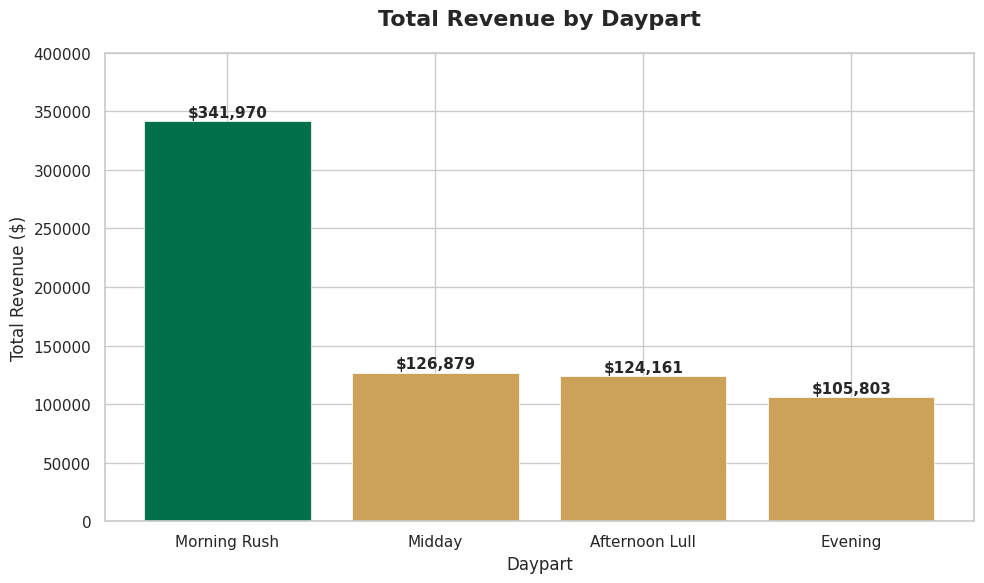

In [113]:
# Chart 1 — Revenue by Daypart
daypart_order = ['Morning Rush', 'Midday', 'Afternoon Lull', 'Evening']
daypart_colors = ['#00704A', '#CBA258', '#CBA258', '#CBA258']  # green for top, gold for rest

daypart_data = q1.set_index('daypart').reindex(daypart_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(daypart_data.index, 
               daypart_data['total_revenue'],
               color=daypart_colors,
               edgecolor='white',
               linewidth=0.5)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'${height:,.0f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total Revenue by Daypart', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daypart', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.ylim(0, 400000)
plt.tight_layout()
plt.show()

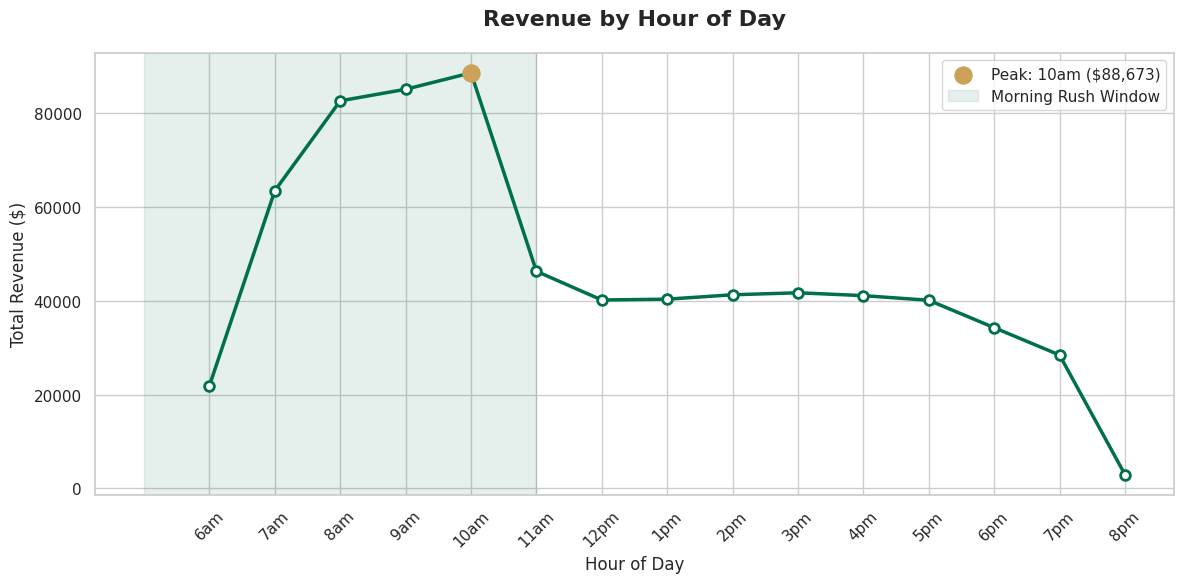

In [114]:
# Chart 2 — Revenue by Hour of Day
# Sort by hour so the line goes left to right chronologically
hourly_data = q4.sort_values('hour')

plt.figure(figsize=(12, 6))
plt.plot(hourly_data['hour'], 
         hourly_data['total_revenue'],
         color='#00704A',
         linewidth=2.5,
         marker='o',
         markersize=7,
         markerfacecolor='white',
         markeredgecolor='#00704A',
         markeredgewidth=2)

# Highlight the peak hour with a special marker
peak_hour = hourly_data.loc[hourly_data['total_revenue'].idxmax()]
plt.scatter(peak_hour['hour'], peak_hour['total_revenue'],
            color='#CBA258', s=150, zorder=5, label=f'Peak: 10am (${peak_hour["total_revenue"]:,.0f})')

# Add shading under morning rush hours
plt.axvspan(5, 11, alpha=0.1, color='#00704A', label='Morning Rush Window')

plt.title('Revenue by Hour of Day', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(hourly_data['hour'], 
           [f'{h}am' if h < 12 else f'{h-12}pm' if h > 12 else '12pm' for h in hourly_data['hour']],
           rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

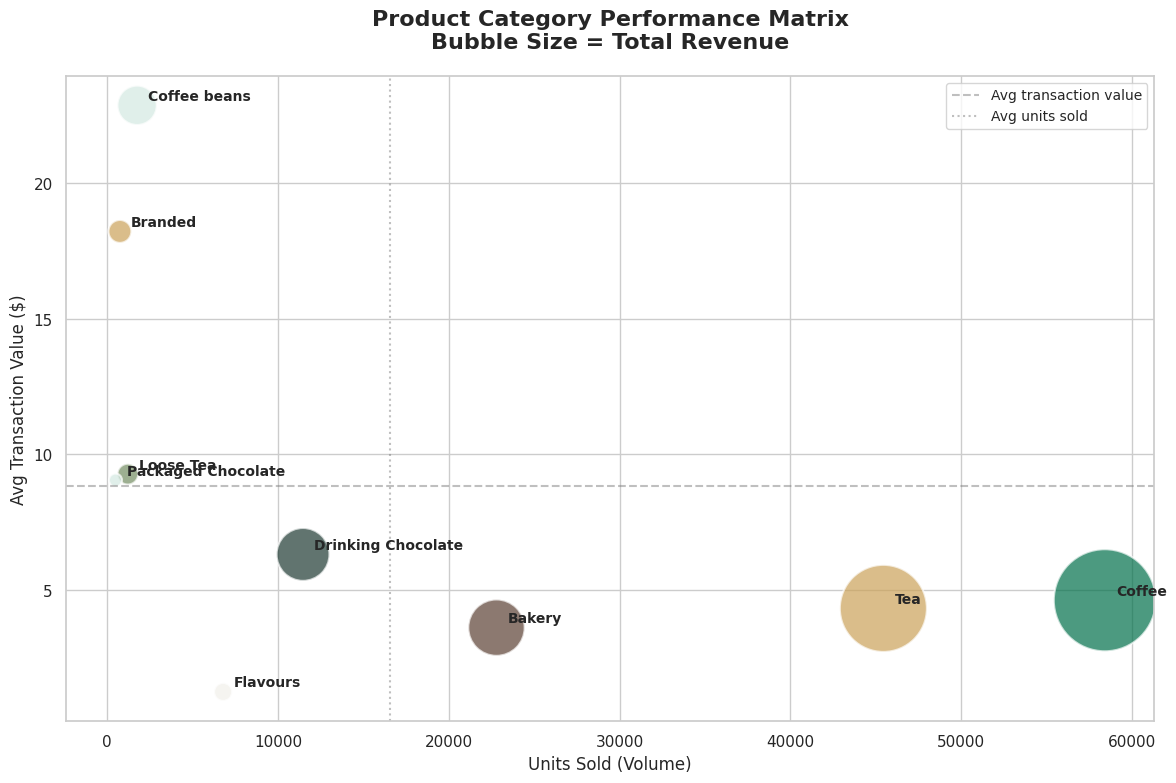

In [115]:
# Chart 3 — Product Category Bubble Chart
# Bubble size = total revenue, X = units sold, Y = avg transaction value

plt.figure(figsize=(12, 8))

# Define colors for each category
colors = ['#00704A', '#CBA258', '#5C4033', '#1E3932', 
          '#D4E9E2', '#CBA258', '#748E63', '#F2F0EB', '#D4E9E2']

scatter = plt.scatter(q2['units_sold'],
                      q2['avg_transaction_value'],
                      s=q2['total_revenue'] / 50,  # bubble size scaled to revenue
                      c=colors,
                      alpha=0.7,
                      edgecolors='white',
                      linewidth=1.5)

# Label each bubble with the category name
for idx, row in q2.iterrows():
    plt.annotate(row['product_category'],
                xy=(row['units_sold'], row['avg_transaction_value']),
                xytext=(8, 4),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

# Add reference lines for averages
plt.axhline(y=q2['avg_transaction_value'].mean(), 
            color='gray', linestyle='--', alpha=0.5, label='Avg transaction value')
plt.axvline(x=q2['units_sold'].mean(), 
            color='gray', linestyle=':', alpha=0.5, label='Avg units sold')

plt.title('Product Category Performance Matrix\nBubble Size = Total Revenue', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Units Sold (Volume)', fontsize=12)
plt.ylabel('Avg Transaction Value ($)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

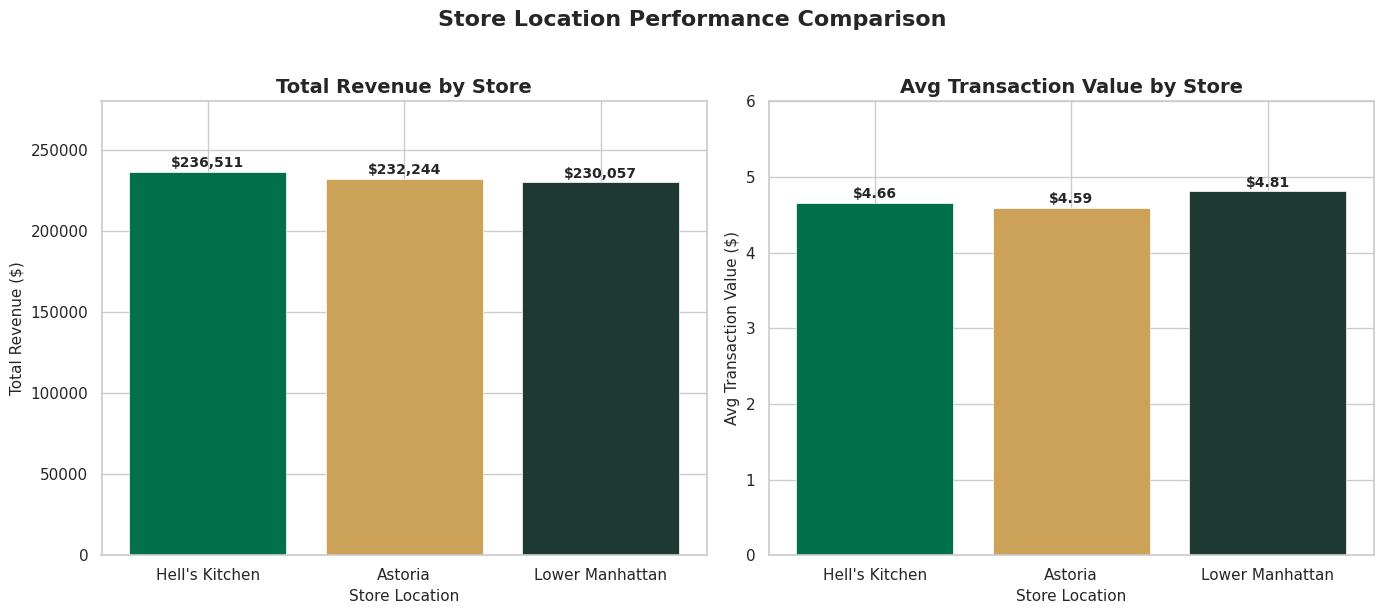

In [116]:
# Chart 4 — Store Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left chart — Total Revenue by Store
bars1 = axes[0].bar(q3['store_location'],
                    q3['total_revenue'],
                    color=['#00704A', '#CBA258', '#1E3932'],
                    edgecolor='white',
                    linewidth=0.5)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1000,
                 f'${height:,.0f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Total Revenue by Store', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Store Location', fontsize=11)
axes[0].set_ylabel('Total Revenue ($)', fontsize=11)
axes[0].set_ylim(0, 280000)

# Right chart — Avg Transaction Value by Store
bars2 = axes[1].bar(q3['store_location'],
                    q3['avg_transaction_value'],
                    color=['#00704A', '#CBA258', '#1E3932'],
                    edgecolor='white',
                    linewidth=0.5)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'${height:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_title('Avg Transaction Value by Store', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store Location', fontsize=11)
axes[1].set_ylabel('Avg Transaction Value ($)', fontsize=11)
axes[1].set_ylim(0, 6)

plt.suptitle('Store Location Performance Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

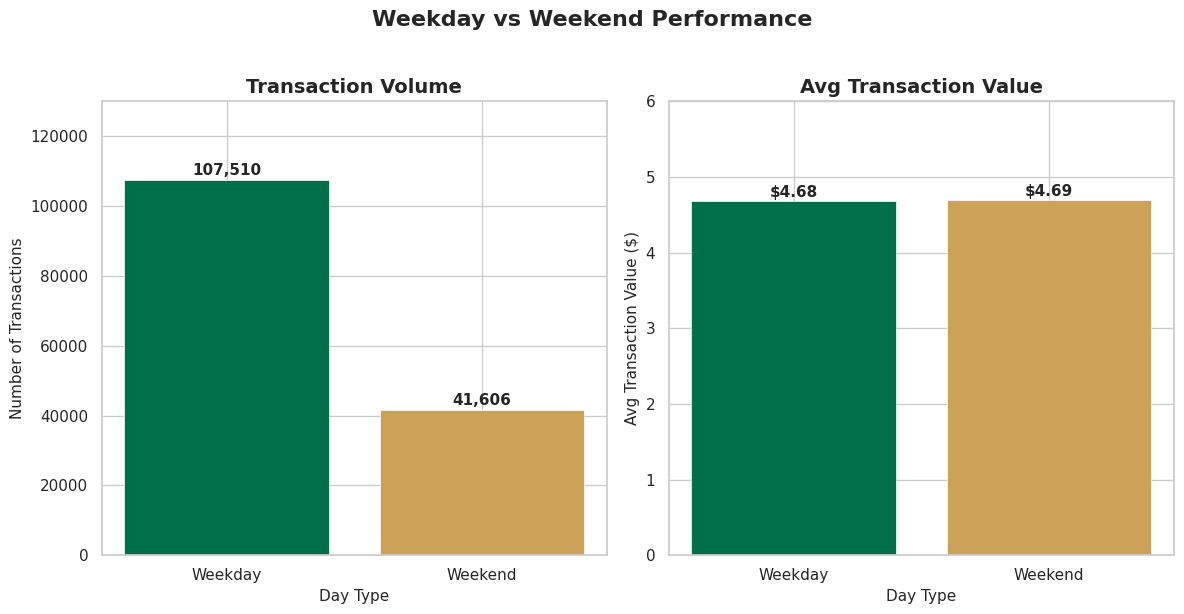

In [117]:
# Chart 5 — Weekend vs Weekday Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

day_types = q5['day_type']
colors = ['#00704A', '#CBA258']

# Left — Transaction Volume
bars1 = axes[0].bar(day_types,
                    q5['transactions'],
                    color=colors,
                    edgecolor='white',
                    linewidth=0.5)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 500,
                 f'{height:,}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Transaction Volume', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day Type', fontsize=11)
axes[0].set_ylabel('Number of Transactions', fontsize=11)
axes[0].set_ylim(0, 130000)

# Right — Average Transaction Value
bars2 = axes[1].bar(day_types,
                    q5['avg_transaction_value'],
                    color=colors,
                    edgecolor='white',
                    linewidth=0.5)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'${height:.2f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_title('Avg Transaction Value', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day Type', fontsize=11)
axes[1].set_ylabel('Avg Transaction Value ($)', fontsize=11)
axes[1].set_ylim(0, 6)

plt.suptitle('Weekday vs Weekend Performance', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [118]:
# Export cleaned dataframe to CSV for Tableau
df.to_csv('coffee_shop_cleaned.csv', index=False)
print("File saved! Download from the output folder on the right sidebar")

File saved! Download from the output folder on the right sidebar


## Key Findings
1. **Morning Rush dominates revenue** — 48% of total revenue 
   generated between 5–11am despite being one of four dayparts; 
   driven entirely by volume not higher spend per customer
   
2. **Peak hour is 10am, not 8am** — revenue builds gradually 
   through the morning and peaks at hour 10 before dropping 
   sharply — staffing should reflect this curve not assume 
   early morning is peak
   
3. **Coffee Beans is the hidden gem** — only 1,753 transactions 
   but $22.87 average transaction value — 5x the store average 
   — making it the highest value category despite ranking 5th 
   in volume
   
4. **All three stores perform within 3% of total revenue** — 
   but Lower Manhattan customers spend $4.81 per visit vs 
   Astoria's $4.59 — suggesting neighborhood-based pricing 
   or product mix opportunities
   
5. **Weekdays generate 72% of revenue** — average transaction 
   value is virtually identical on weekends ($4.69) vs weekdays 
   ($4.68) confirming this is a commuter-driven business where 
   weekend traffic is significantly underutilized

## Business Recommendations
1. Front-load staffing and inventory investment to the 
   7–11am window — particularly the 9–10am peak — rather 
   than spreading resources evenly across the day
   
2. Actively promote Coffee Beans through sampling or bundling 
   — a small increase in Coffee Bean transaction volume would 
   meaningfully impact total revenue given the $22.87 avg ticket
   
3. Develop a weekend traffic strategy — since spending behavior 
   is identical on weekends, the only barrier to weekend revenue 
   is foot traffic — targeted promotions or events could close 
   the gap


## Limitations and Next Steps
- Dataset covers one chain — findings may not generalize 
  to other coffee shop formats or non-urban locations
- No customer-level data — unable to analyze loyalty, 
  repeat visit rates, or customer lifetime value
- Next step: Incorporate weather data to test whether 
  temperature and precipitation affect daypart performance

## Project Links
- [View Interactive Dashboard on Tableau Public](https://public.tableau.com/app/profile/brenna.coe/viz/CoffeeShopSalesAnalysis_17850996209000/Dashboard1?publish=yes)
- [View Code on GitHub](your-github-url)